<a href="https://colab.research.google.com/github/KrzysztofDrobnik/lecture1/blob/regresja/PUM5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

<ipython-input-2-9f69f8392d9a>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


100%|██████████| 18.9k/18.9k [00:00<00:00, 17.5MB/s]

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [6]:
for col in df.columns:
  mean = df[col].mean()
  df[col].fillna(mean, inplace = True)

<ipython-input-6-8336c44fcfa3>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean, inplace = True)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [9]:
X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

y_pred = linear_regression.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

coef = linear_regression.coef_
intercept = linear_regression.intercept_
age = coef[0]
gender = coef[1]
edu = coef[2]
job = coef[3]
years = coef[4]
print(f"Model ma postać: Y = age*{age} + gedner*{gender} + education*{edu} + job title*{job} + experience*{years} + {intercept}")

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Model ma postać: Y = age*3352.8783199155787 + gedner*6505.179577813024 + education*13695.97444713433 + job title*34.4109189709543 + experience*2365.555051005106 + -62874.171054994615
Mean Squared Error: 269335248.36463064
Mean Absolute Error: 11034.937092871898
R-squared: 0.8888191777593424


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

               feature        VIF
0                  Age  15.129201
1               Gender   2.047736
2      Education Level   2.330338
3            Job Title   4.892569
4  Years of Experience   9.426853


Spróbuj poprawić wynik używając regresji LASSO

In [13]:
lasso_regression = Lasso(alpha=1.0, fit_intercept=True, precompute=False, copy_X=True, max_iter=1000, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
lasso_regression.fit(X_train, y_train)

y_pred = lasso_regression.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

coef = linear_regression.coef_
intercept = linear_regression.intercept_
age = coef[0]
gender = coef[1]
edu = coef[2]
job = coef[3]
years = coef[4]
print(f"Model ma postać: Y = age*{age} + gedner*{gender} + education*{edu} + job title*{job} + experience*{years} + {intercept}")

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Model ma postać: Y = age*3352.8783199155787 + gedner*6505.179577813024 + education*13695.97444713433 + job title*34.4109189709543 + experience*2365.555051005106 + -62874.171054994615
Mean Squared Error: 269337775.29624027
Mean Absolute Error: 11034.823221839672
R-squared: 0.8888181346491821


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [19]:
df['Experience_Square'] = df["Years of Experience"]**2

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

y_pred = linear_regression.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

coef = linear_regression.coef_
intercept = linear_regression.intercept_
age = coef[0]
gender = coef[1]
edu = coef[2]
job = coef[3]
years = coef[4]
job_2 = coef[5]
print(f"Model ma postać: Y = age*{age} + gedner*{gender} + education*{edu} + job title*{job} + experience*{years} + job_2*{job_2}+ {intercept}")

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)



Model ma postać: Y = age*3218.4025222834675 + gedner*6674.699654631246 + education*13759.18545888481 + job title*23.458813797937637 + experience*3084.7318131937336 + job_2*-25.621019119500488+ -60544.577219029525
Mean Squared Error: 272356707.37663
Mean Absolute Error: 10977.000790143727
R-squared: 0.8875719280979623


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

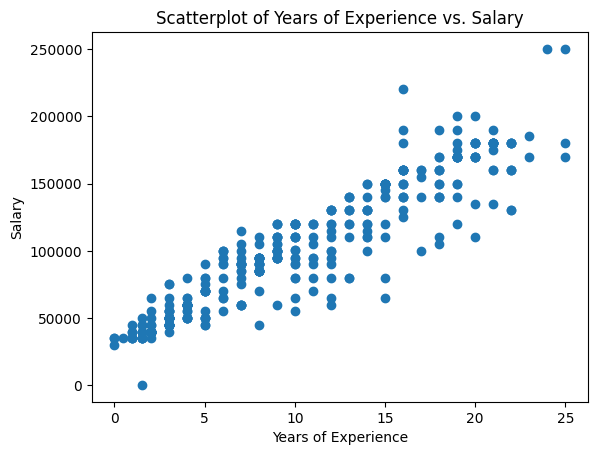

In [17]:
plt.figure()
plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Scatterplot of Years of Experience vs. Salary')
plt.show()

#bardziej krzywa niż prosta = regrejsa uzasadniona?


Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

In [21]:
from sklearn.neighbors import KNeighborsRegressor
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)
y_pred_knn = knn_regressor.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression:")
print("Mean Squared Error:", mse_knn)
print("Mean Absolute Error:", mae_knn)
print("R-squared:", r2_knn)

KNN Regression:
Mean Squared Error: 247761376.22211522
Mean Absolute Error: 11166.24164432529
R-squared: 0.8977248106398646


Regresja wielomianowa 2 stopnia

In [22]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Predykcja
y_pred_poly = poly_reg.predict(X_test_poly)

# Ocena modelu
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression (Degree 2):")
print("Mean Squared Error:", mse_poly)
print("Mean Absolute Error:", mae_poly)
print("R-squared:", r2_poly)

Polynomial Regression (Degree 2):
Mean Squared Error: 432101953.5975163
Mean Absolute Error: 12592.99211027803
R-squared: 0.8216295461345371


In [24]:
from sklearn.model_selection import RepeatedKFold
# Define the models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "K-NN Regression": KNeighborsRegressor(),
    "Polynomial Regression (Degree 2)": LinearRegression()  # We'll apply PolynomialFeatures separately
}

# Create RepeatedKFold object
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# Initialize dictionary to store results for each model
results = {}

# Loop through each model
for model_name, model in models.items():
    mse_scores = []
    mae_scores = []
    r2_scores = []

    # Loop through the folds
    for train_index, test_index in rkf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Apply PolynomialFeatures if it's Polynomial Regression
        if model_name == "Polynomial Regression (Degree 2)":
            poly = PolynomialFeatures(degree=2)
            X_train = poly.fit_transform(X_train)
            X_test = poly.transform(X_test)

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions and calculate metrics
        y_pred = model.predict(X_test)
        mse_scores.append(mean_squared_error(y_test, y_pred))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    # Store results for the current model
    results[model_name] = {
        "Average MSE": np.mean(mse_scores),
        "Average MAE": np.mean(mae_scores),
        "Average R-squared": np.mean(r2_scores)
    }

# Print the results for all models
for model_name, metrics in results.items():
    print(f"Results for {model_name}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value}")
    print("\n")

Results for Linear Regression:
Average MSE: 257249946.52865338
Average MAE: 11439.847533535354
Average R-squared: 0.8862718378497975


Results for Lasso Regression:
Average MSE: 257249706.08309647
Average MAE: 11439.83977328034
Average R-squared: 0.8862718143948365


Results for K-NN Regression:
Average MSE: 327618096.92401004
Average MAE: 11947.180282394995
Average R-squared: 0.8539169724013321


Results for Polynomial Regression (Degree 2):
Average MSE: 239838935.30144137
Average MAE: 10541.158692889174
Average R-squared: 0.8949777924689158


